<!-- Markdown cell content starts -->
<!DOCTYPE html>
<html>
<head>
<style>
  body {
    background: #0f172a;
    color: #e5e7eb;
    font-family: Inter, sans-serif;
  }
  .assignment {
    max-width: 900px;
    margin: auto;
    padding: 20px;
    background: #1f2937;
    border-radius: 12px;
    border: 1px solid #374151;
  }
  h1 {
    color: #22d3ee;
  }
  h2 {
    border-left: 4px solid #22d3ee;
    padding-left: 8px;
  }
  table {
    width: 100%;
    border-collapse: collapse;
    margin-top: 12px;
  }
  th, td {
    border: 1px solid #374151;
    padding: 8px;
    text-align: left;
  }
  th {
    background: #111827;
  }
</style>
</head>
<body>
<div class="assignment">
  <h1>Computer Vision Assignment</h1>
  <p><strong>Course:</strong> Computer Vision<br>
     <strong>Deadline:</strong> 24 avar 1404 <br>
     <strong>Total Points:</strong> 100</p>

  <h2>Objective</h2>
  <ol>
    <li>Use pretrained CNNs for classification, detection, segmentation</li>
    <li>Perform preprocessing</li>
    <li>Run inference on input images</li>
    <li>Evaluate results</li>
  </ol>

  <h2>Grading Breakdown</h2>
  <table>
    <tr><th>Criterion</th><th>Description</th><th>Points</th></tr>
    <tr><td>Correct preprocessing</td><td>Resizing, normalization, tensor conversion</td><td>20</td></tr>
    <tr><td>Correct model usage</td><td>Proper pretrained model inference</td><td>20</td></tr>
    <tr><td>Visualization quality</td><td>Clear side-by-side figures</td><td>20</td></tr>
    <tr><td>Analysis and discussion</td><td>Interpretation and insights</td><td>40</td></tr>
    <tr><td colspan="2"><strong>Total</strong></td><td><strong>100</strong></td></tr>
  </table>

  <h4>Answer all questions colored in red, or complete all parts in "#TO DO" sections.</h4>

</div>
</body>
</html>
<!-- Markdown cell content ends -->


## 0. Setup and Installation

In [1]:
# !pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install -q timm segment-anything ultralytics
# !pip install -q pillow matplotlib

# Import Required Libraries

In [2]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from ultralytics import YOLO
import timm
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

C:\Users\NoteBook\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 1. Show All Input Images
<span style="color:red">
Plot all the images in a single figure.
</span>

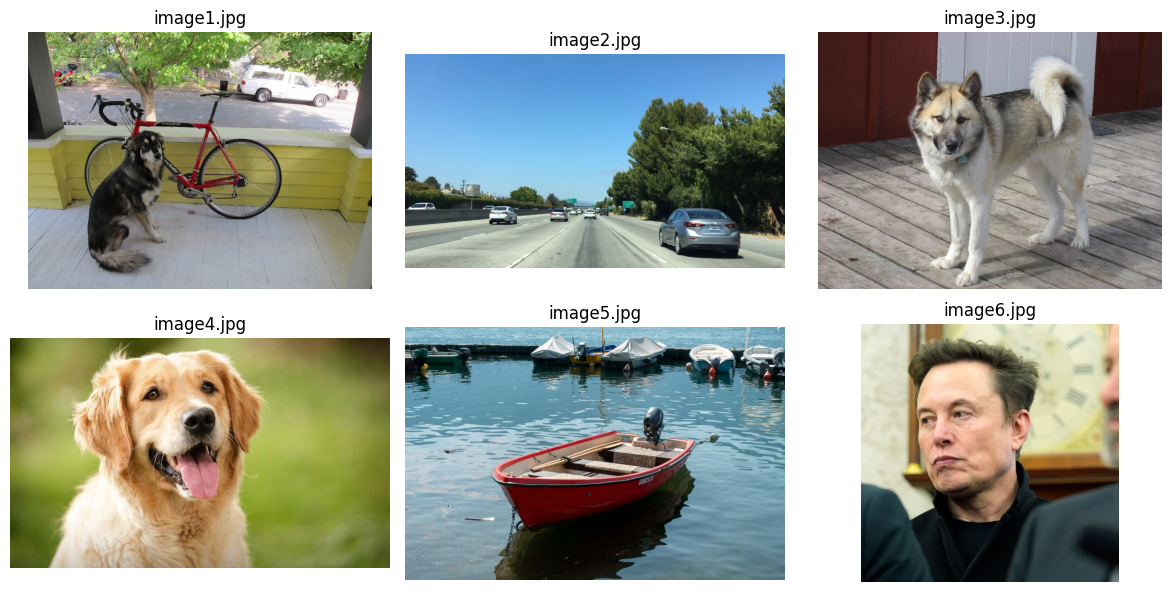

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = os.path.join("data", "dataset")

images = [f for f in os.listdir(dataset_path) if f.lower().endswith(".jpg")]

plt.figure(figsize=(12, 6))

for i, img_name in enumerate(images[:6]): 
    img_path = os.path.join(dataset_path, img_name)
    img = mpimg.imread(img_path)
    
    plt.subplot(2, 3, i + 1)  # 2 rows, 3 columns
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


---
## 2. Task 1 – Image Classification
---
In this task, you are to use pretrained **EfficientNet-B4** model from torchvision/timm with 1000 classes. 

<span style="color:red">
Explain the functionality of the model briefly and indicate the dataset it is trained on.
</span>

**Required preprocessing**:
You are asked to design and apply a **12‑step preprocessing pipeline** to prepare real‑world images for classification with EfficientNet‑B4. 

<span style="color:red"> For each step, briefly explain why it is useful.</span>


### Steps to include:
1. Convert to NumPy for OpenCV operations
2. Apply Gaussian blur  
3. Perform unsharp masking – Enhance edges and improve clarity
4. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)improve local contrast.
5. Convert back to PIL format.
6. Pad to square shape – Preserve aspect ratio before resizing.
7. Resize with high‑quality antialiasing.
8. Apply random rotation and random crop.
9. Apply color jitter and random grayscale.
10. Convert to tensor.
11. Normalize with ImageNet mean and std.
12. Add batch dimension.


### What is the functionality of **EfficientNet-B4**?

**EfficientNet-B4** is a deep convolutional neural network designed for high-accuracy image classification while being computationally efficient. It belongs to the **EfficientNet family**, a set of models that scale depth, width, and input resolution in a balanced way using *compound scaling*.

Functionalities:
- **Image Classification**: Takes an image as input and predicts which class it belongs to.
- **Feature Extraction**: Can be used as a backbone for tasks like object detection, segmentation, and transfer learning.
- **Efficiency**: Uses fewer parameters and FLOPs compared to older architectures (like ResNet or Inception) while achieving higher accuracy.

### What dataset **EfficientNet-B4** is trained on?

EfficientNet-B4 is **pretrained on the ImageNet dataset** specifically on **ImageNet (ILSVRC 2012, ImageNet-1K)**. 

It has 
- **1,000 classes**
- **~1.2 million training images**
- Large, diverse dataset used to benchmark image classification models.

This pretraining enables EfficientNet-B4 to learn strong general features such as edges, textures, shapes, and object structures.


### Explain of each preprocessing step:

1. **Convert to NumPy for OpenCV operations**: OpenCV functions work on NumPy arrays, so converting the image to this format allows for applying various image processing operations like blurring or edge detection, which OpenCV handles more efficiently than PIL.

2. **Apply Gaussian blur**: Gaussian blur smooths the image by averaging pixel values in a neighborhood, which helps in reducing noise and detail, making subsequent processing steps, like edge detection, clearer and more accurate.

3. **Perform unsharp masking – Enhance edges and improve clarity**: Unsharp masking sharpens the image by subtracting a blurred version of the image from the original, enhancing edges and fine details to make the image appear clearer and more defined.

4. **Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)**: CLAHE enhances the local contrast in different regions of the image, making it particularly useful for improving visibility in images with varying lighting conditions, ensuring details are more distinct.

5. **Convert back to PIL format**: Converting back to PIL allows us to easily use PIL-based functions for further image manipulation, ensuring compatibility with the preprocessing pipeline in PyTorch or other image libraries.

6. **Pad to square shape – Preserve aspect ratio before resizing**: Padding the image ensures that its aspect ratio remains intact by adding borders, making it square before resizing, which avoids distortion during the resizing process.

7. **Resize with high‑quality antialiasing**: Resizing with antialiasing ensures that when the image is scaled down, fine details and edges are preserved without introducing jagged edges or distortions, producing a smoother and higher-quality result.

8. **Apply random rotation and random crop**: Random rotation and cropping introduce variability to the image, which helps in making the model more robust to different orientations and positions of objects, enhancing generalization.

9. **Apply color jitter and random grayscale**: Color jitter alters the brightness, contrast, saturation, and hue of the image, making the model more invariant to lighting conditions, while random grayscale forces the model to learn without relying on color information, improving its ability to recognize objects in black-and-white scenarios.

10. **Convert to tensor**: Converting the image to a tensor is necessary for PyTorch models, as they expect input data to be in tensor form, enabling efficient computation on the GPU or CPU.

11. **Normalize with ImageNet mean and std**: Normalizing the image with the ImageNet mean and standard deviation ensures that the input features are scaled similarly to the data the model was trained on, which helps improve model performance by stabilizing training.

12. **Add batch dimension**: Adding a batch dimension is necessary because models in PyTorch expect a batch of images (even if it's just one image), and this step allows the model to process multiple images simultaneously, even if we're only passing a single image.


Evaluating image3.jpg...



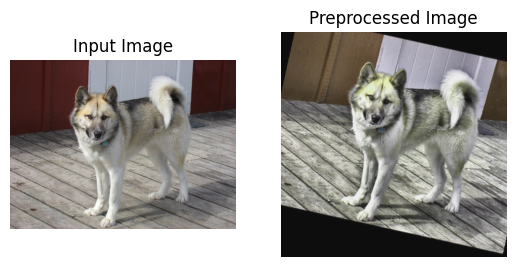

Top predictions:
malamute: 49.05%
Norwegian elkhound: 6.77%
Eskimo dog: 5.78%
Siberian husky: 2.82%
timber wolf: 1.14%
Evaluating image4.jpg...



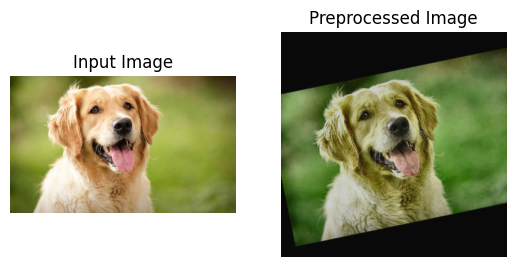

Top predictions:
golden retriever: 49.30%
Labrador retriever: 2.36%
Brittany spaniel: 2.25%
kuvasz: 1.09%
clumber: 0.87%
Evaluating image5.jpg...



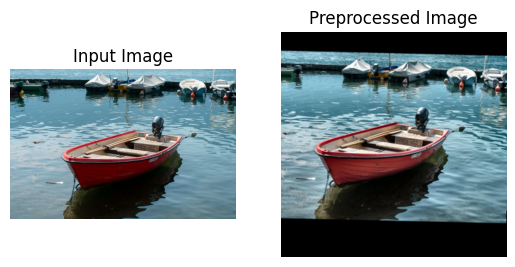

Top predictions:
canoe: 12.30%
paddle: 10.00%
lakeside: 6.93%
speedboat: 4.74%
boathouse: 4.29%
Evaluating image6.jpg...



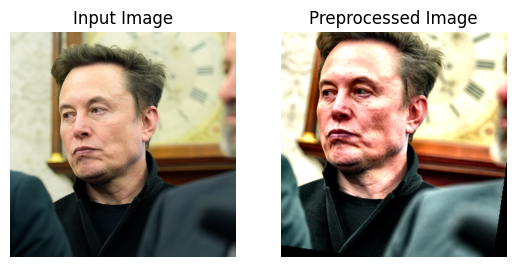

Top predictions:
wall clock: 14.91%
analog clock: 9.23%
barometer: 4.72%
barbershop: 4.44%
banjo: 2.70%


In [4]:
import timm
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image, ImageFilter, ImageOps
import requests
import matplotlib.pyplot as plt
import numpy as np
import cv2
from typing import Tuple

# Load model once
class_model = timm.create_model("efficientnet_b4", pretrained=True)

class_model.eval().to(device)

# ImageNet labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = requests.get(url).text.strip().split("\n")

# Preprocessing
def preprocessing(img: Image.Image) -> torch.Tensor:
    """
    12-step preprocessing.
    Returns: tensor ready for EfficientNet-B4
    """
    # 1. Convert to NumPy for OpenCV operations
    np_img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    # 2. Apply Gaussian blur
    blurred = cv2.GaussianBlur(np_img, (5, 5), 0)

    # 3. Perform unsharp masking – enhance edges
    amount = 1.5
    np_img = cv2.addWeighted(np_img, 1 + amount, blurred, -amount, 0)

    # 4. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    lab = cv2.cvtColor(np_img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    np_img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    
    # 5. Convert back to PIL format
    img = Image.fromarray(cv2.cvtColor(np_img, cv2.COLOR_BGR2RGB))
    
    # 6. Pad to square shape
    w, h = img.size
    max_side = max(w, h)
    pad_w = (max_side - w) // 2
    pad_h = (max_side - h) // 2
    img = ImageOps.expand(img, border=(pad_w, pad_h, max_side - w - pad_w, max_side - h - pad_h), fill=(0,0,0))
    
    # 7. Resize with high-quality antialiasing
    target_size = 380
    img = img.resize((target_size, target_size), Image.Resampling.LANCZOS)
    
    # 8. Apply random rotation and random crop
    # Random rotation between -15 and +15 degrees
    angle = np.random.uniform(-15, 15)
    img = img.rotate(angle, resample=Image.Resampling.BILINEAR)

    crop_size = int(target_size * 0.9)
    left = np.random.randint(0, target_size - crop_size + 1)
    top = np.random.randint(0, target_size - crop_size + 1)
    img = img.crop((left, top, left + crop_size, top + crop_size))
    img = img.resize((target_size, target_size), Image.Resampling.LANCZOS)

    # 9. Apply color jitter and random grayscale
    # Color jitter (brightness, contrast, saturation, hue)
    color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    img = color_jitter(img)

    # Randomly convert to grayscale with probability of 0.1
    if np.random.rand() < 0.1:
        img = img.convert("L").convert("RGB")
    
    # 10. Convert to tensor
    tensor = transforms.ToTensor()(img)

    # 11. Advanced normalization: subtract mean and divide by std per channel
    tensor = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])(tensor)

    # 12. Add batch dimension
    return tensor.unsqueeze(0).to(device)

# Classify
def classify(img: Image.Image, topk: int = 5):
    # First preprocess the input image, then feed it to the network
    preprocessed_image = preprocessing(img)
    with torch.no_grad():
        output = class_model(preprocessed_image)
    
    probs = F.softmax(output[0], dim=0)
    top_prob, top_idx = torch.topk(probs, topk)
    top_prob = top_prob.cpu().numpy()
    top_idx = top_idx.cpu().numpy()

    tensor_img = preprocessed_image.squeeze().cpu()

    # If tensor is normalized, undo normalization (example for ImageNet mean/std)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    tensor_img = tensor_img * std[:, None, None] + mean[:, None, None]

    # Convert to numpy and transpose to HWC
    tensor_img = tensor_img.numpy().transpose(1, 2, 0)

    # Plot both original and preprocessed tensor
    fig, (ax1, ax2) = plt.subplots(1, 2)

    ax1.imshow(img)
    ax1.set_title("Input Image")
    ax1.axis('off')
    ax2.imshow(tensor_img)
    ax2.set_title("Preprocessed Image")
    ax2.axis('off')
    plt.show()

    # Print top 5 prediction result for the preprocessed image
    print("Top predictions:")
    for i in range(topk):
        print(f"{imagenet_classes[top_idx[i]]}: {top_prob[i]*100:.2f}%")


# Evaluate the model one Image3, Image4, Image5, and Image6
image_names = ["image3.jpg", "image4.jpg", "image5.jpg", "image6.jpg"]

for img_name in image_names:
    img_path = os.path.join(dataset_path, img_name)
    img = Image.open(img_path)

    print(f"Evaluating {img_name}...\n")

    classify(img) 


| Model (year)                        |                                                    Short idea / use |       Canonical depth (label) |                                              Typical params (≈) | Pretrained on (dataset)                                                          |
| ----------------------------------- | ------------------------------------------------------------------: | ----------------------------: | --------------------------------------------------------------: | -------------------------------------------------------------------------------- |
| **AlexNet** (2012)                  |                   Big conv + FC; revived deep learning for ImageNet |      8 layers (5 conv + 3 fc) |                                      **~60M**. ([Wikipedia][1]) | ImageNet (ILSVRC2012), **1,000 classes**, ~1.2M images. ([Wikipedia][1])         |
| **VGG-16 / VGG-19** (2014)          |                   Very deep stack of 3×3 convs (simple, expressive) |         16 / 19 weight layers |              **VGG-16 ≈ 138M**, VGG-19 ≈ 144M. ([Wikipedia][2]) | ImageNet, 1,000 classes. ([Wikipedia][2])                                        |
| **GoogLeNet / Inception-v1** (2014) | Inception modules (multi-scale), global avg pool → far fewer params |                    ~22 layers | **~6.8M** (very small compared to VGG). ([Computer Science][3]) | ImageNet / ILSVRC2014, 1,000 classes. ([Computer Science][3])                    |
| **ResNet-50** (2015)                |                     Residual connections → very deep nets trainable | 50 layers (Bottleneck blocks) |                    **~25.6M**. ([paddleclas.readthedocs.io][4]) | ImageNet, 1,000 classes. ([paddleclas.readthedocs.io][4])                        |
| **DenseNet-121** (2016)             |           Dense connectivity (feature reuse) → parameter efficiency |           “121” configuration |                     **~7.9M**. ([paddleclas.readthedocs.io][8]) | ImageNet, 1,000 classes. ([arXiv][5])                                            |
| **MobileNet-V1** (2017)             |                  Depthwise-separable convs for tiny / mobile models |           ~28 layers (varies) |               **~4.2M** (for common α=1.0 config). ([arXiv][6]) | ImageNet, 1,000 classes. ([arXiv][6])                                            |
| **EfficientNet-B4** (2019)          | Compound scaling (depth×width×res) — accuracy vs compute sweet-spot |           scaled variant (B4) |                                   **~19M** (B4). ([viso.ai][9]) | ImageNet-1K (pretrained weights commonly available), 1,000 classes. ([arXiv][7]) |



## 3. Task 2 – Object Detection
In this task, you are to use pretrained **R-CNN ResNet50-FPN-v2** model for object detection task.

<span style="color:red">
Explain the functionality of the model briefly and indicate the dataset it is trained on.
</span>

### Explanation of **R-CNN ResNet50-FPN-v2**:

The **R-CNN ResNet50-FPN-v2** model is a state-of-the-art deep learning model used for **object detection** tasks. It is based on a **Region-based Convolutional Neural Network (R-CNN)** architecture, which efficiently detects objects in images by generating region proposals and classifying them. The model utilizes a **ResNet50** backbone combined with a **Feature Pyramid Network (FPN)**, which helps in detecting objects at different scales. The **FPN** is designed to improve the model’s performance, especially in detecting smaller objects, by building a multi-scale feature map.

This model is pretrained on the **COCO (Common Objects in Context) dataset**, which contains over 300,000 labeled images across 80 object categories, making it highly effective for a wide range of object detection tasks.


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to C:\Users\NoteBook/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth
100%|██████████| 167M/167M [12:36<00:00, 232kB/s]  



Evaluating image1.jpg...



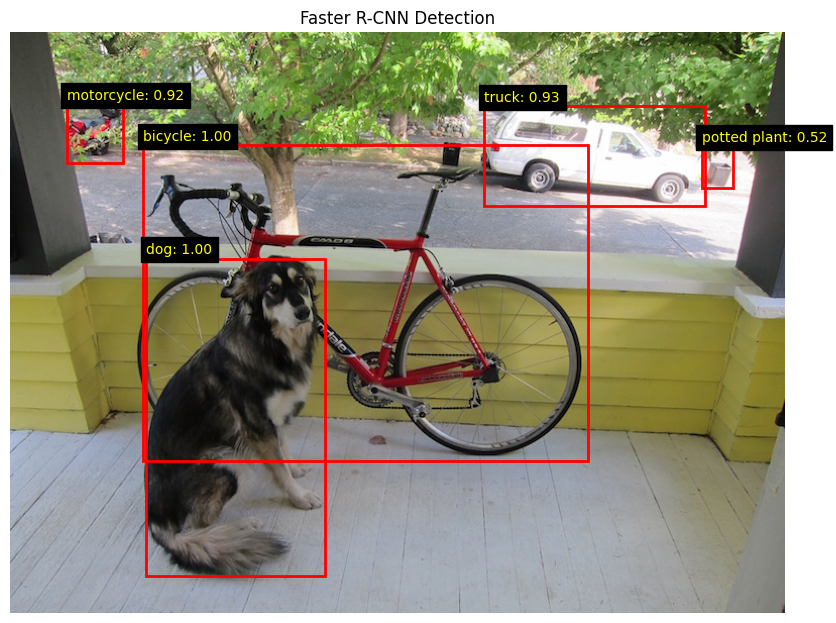


Evaluating image2.jpg...



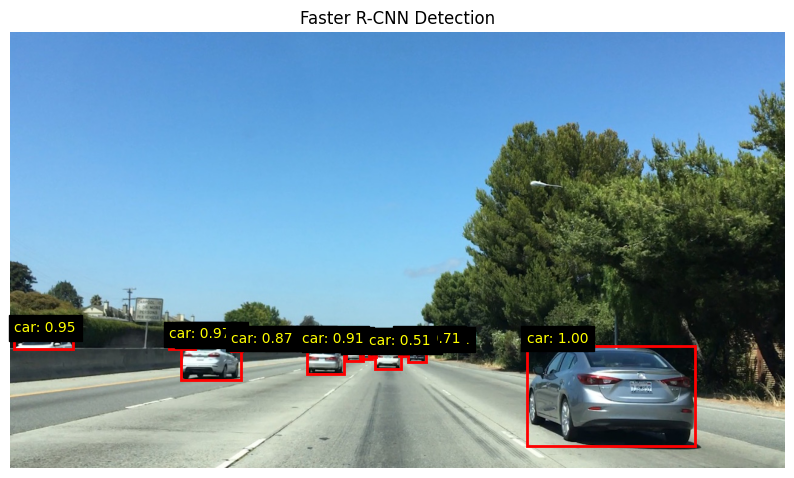

In [5]:
# Fixed Faster R-CNN
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
import torchvision.transforms as T

weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)
model.eval()
model.to('cpu')  # <- crucial!

transform = weights.transforms()

def frcnn_detect(img):
    # Apply the pretrained transform
    img_t = transform(img).unsqueeze(0)  # Adding batch dimension
    
    with torch.no_grad():
        predictions = model(img_t)[0]

    # Extract outputs
    boxes = predictions["boxes"]
    labels = predictions["labels"]
    scores = predictions["scores"]

    boxes = boxes.numpy()
    labels = labels.numpy()
    scores = scores.numpy()

    threshold = 0.5
    keep = scores >= threshold
    boxes = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]

    img_np = np.array(img)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_np)

    ax = plt.gca()

    for box, lbl, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box

        # Draw bounding box
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             fill=False, edgecolor="red", linewidth=2)
        ax.add_patch(rect)

        # Display label & score
        class_name = weights.meta["categories"][lbl]
        ax.text(x1, y1 - 5, f"{class_name}: {score:.2f}",
                color="yellow", fontsize=10, backgroundcolor="black")

    plt.axis("off")
    plt.title("Faster R-CNN Detection")
    plt.show()

    return boxes, labels, scores


# Feed Image1 and Image2 to the model and evaluate it
image_names = ["image1.jpg", "image2.jpg"]

for img_name in image_names:
    img_path = os.path.join(dataset_path, img_name)
    img = Image.open(img_path)

    print(f"\nEvaluating {img_name}...\n")
    frcnn_detect(img)


## 4. Task 3 – Semantic Segmentation

In this task, you are to use the pretrained **DeepLabV3+ with ResNet50 backbone (torchvision)** model for a segemntation task.

<span style="color:red">
Load the model using the "COCO_WITH_VOC_LABELS_V1" weights.

Do the required preprocessing
</span>


--- Running segmentation on image2.jpg ---


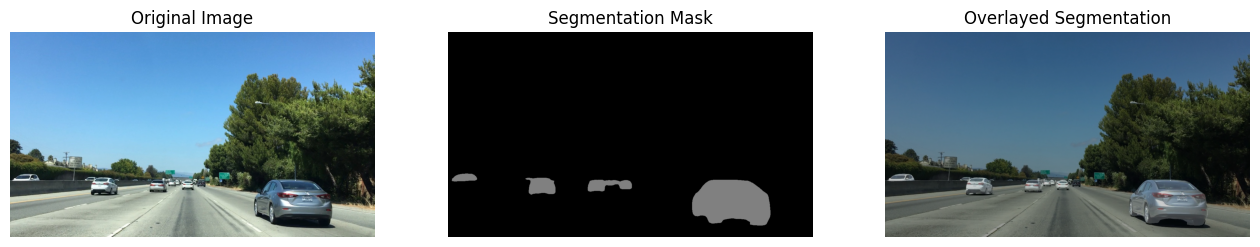


--- Running segmentation on image3.jpg ---


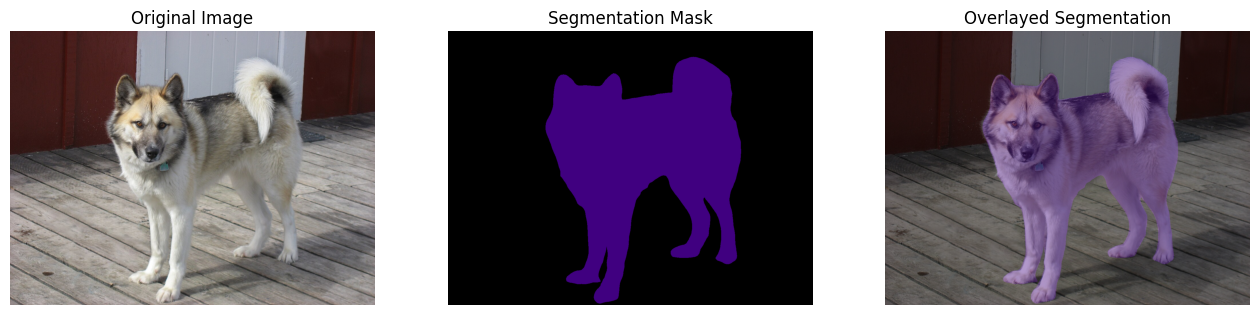


--- Running segmentation on image6.jpg ---


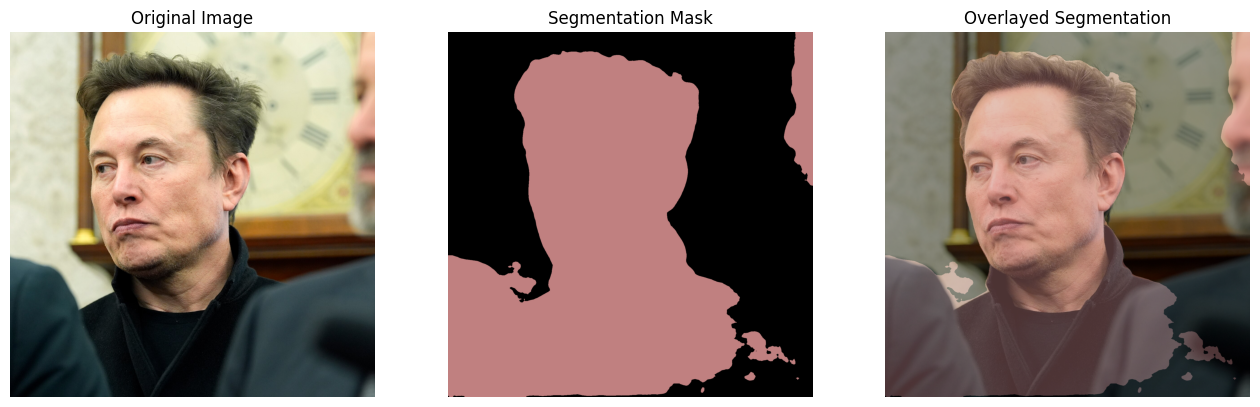

In [8]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import torchvision.transforms as transforms
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seg_model = deeplabv3_resnet50(
    weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
)
seg_model.eval()
seg_model.to(device)

seg_preprocess = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# IMPORTANT FOR ME
# This is the built and exact transformation pipeline the model was trained with.
# weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
# seg_preprocess = weights.transforms()

# PASCAL VOC colors (21 classes)
VOC_COLORS = np.array([
    [0, 0, 0],      # background
    [128, 0, 0],    # aeroplane
    [0, 128, 0],    # bicycle
    [128, 128, 0],  # bird
    [0, 0, 128],    # boat
    [128, 0, 128],  # bottle
    [0, 128, 128],  # bus
    [128, 128, 128],# car
    [64, 0, 0],     # cat
    [192, 0, 0],    # chair
    [64, 128, 0],   # cow
    [192, 128, 0],  # dining table
    [64, 0, 128],   # dog
    [192, 0, 128],  # horse
    [64, 128, 128], # motorbike
    [192, 128, 128],# person
    [0, 64, 0],     # potted plant
    [128, 64, 0],   # sheep
    [0, 192, 0],    # sofa
    [128, 192, 0],  # train
    [0, 192, 128]   # tv/monitor
])

def segment_image(img):
    # Preprocess the image (PIL → tensor → normalized)
    input_tensor = seg_preprocess(img).unsqueeze(0).to(device)

    # Model inference
    with torch.no_grad():
        output = seg_model(input_tensor)['out'][0]   # shape: [21, H, W]

    # Convert to class mask
    pred = output.argmax(0).cpu().numpy()

    # Create colored mask 
    color_mask = VOC_COLORS[pred] 

    # colored mask on original image
    img_np = np.array(img).astype(np.float32)
    overlay = (0.6 * img_np + 0.4 * color_mask).astype(np.uint8)

    # original, mask, and overlay
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img_np.astype(np.uint8))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(color_mask)
    plt.title("Segmentation Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlayed Segmentation")
    plt.axis("off")

    plt.show()

    return pred

# Evaluate the model on Image2, Image3, and Image6
image_names = ["image2.jpg", "image3.jpg", "image6.jpg"]

for name in image_names:
    img_path = os.path.join(dataset_path, name)
    
    if not os.path.exists(img_path):
        print(f"File not found: {img_path}")
        continue

    img = Image.open(img_path).convert("RGB")

    print(f"\n--- Running segmentation on {name} ---")
    pred_mask = segment_image(img)